# 此為給一張圖做卷積，並轉成特徵圖的練習

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

Image Shape: (216, 384, 3)


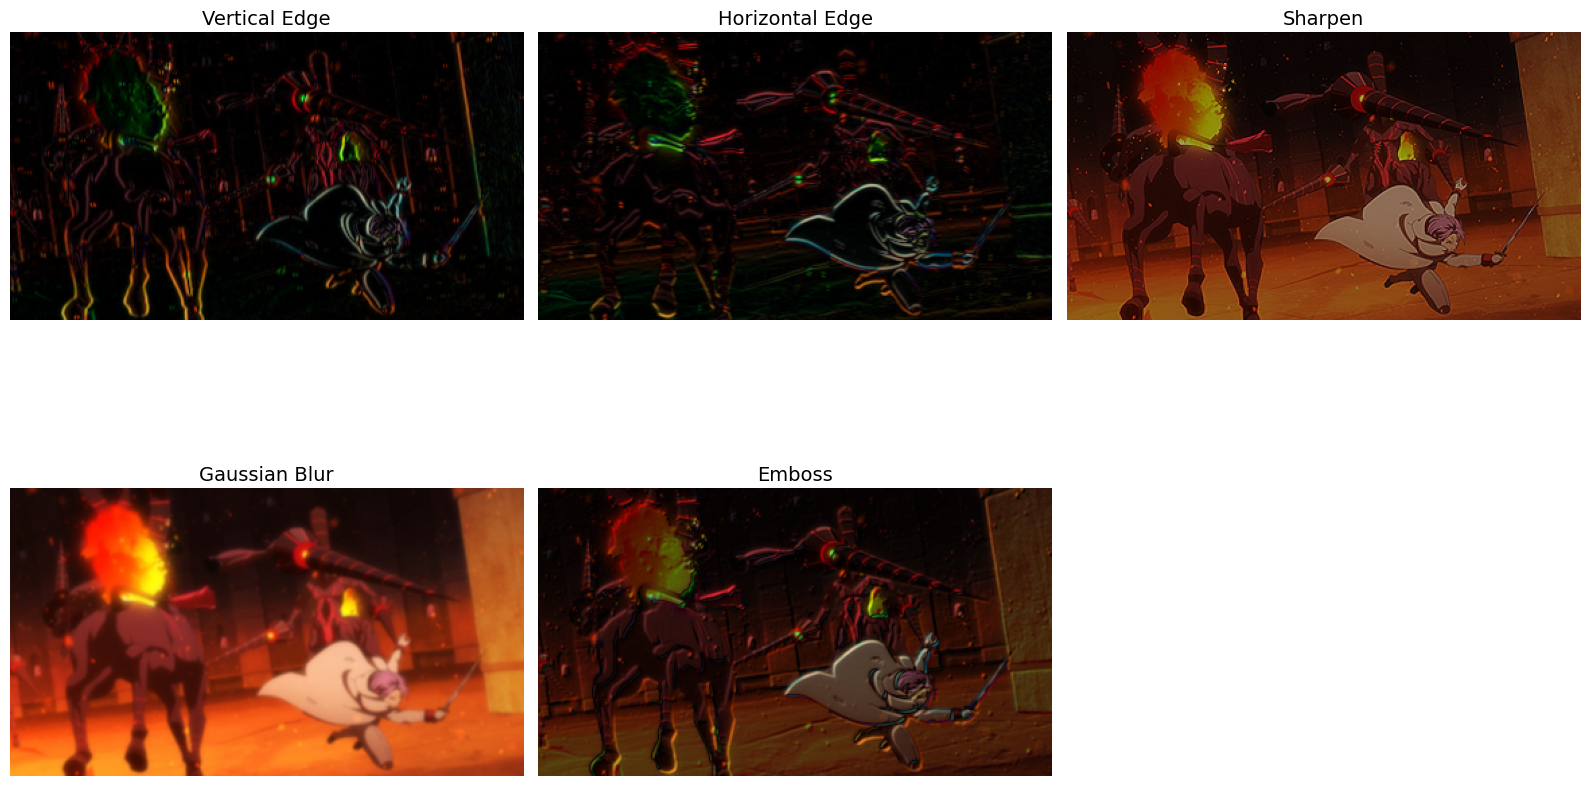

In [ ]:
# 讀取圖片
img = Image.open("葬送的芙莉蓮 第二季 [38]1778821895866.png")

# 大小resize
img_small = img.resize((384, 216))

# 轉 numpy array (RGB)
I = np.array(img_small)[:, :, :3]
print("Image Shape:", I.shape)

# 定義 kernels
kernels = {

    "Vertical Edge": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]]),

    "Horizontal Edge": np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]]),

    "Sharpen": np.array([
        [ 0, -1,  0],
        [-1,  5, -1],
        [ 0, -1,  0]]),

    "Gaussian Blur": (1/16) * np.array([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]]),

    "Emboss": np.array([
        [-2, -1, 0],
        [-1,  1, 1],
        [ 0,  1, 2]])
}
# RGB convolution

def convolution_rgb_color(I, K):
    I_h, I_w, I_c = I.shape
    K_h, K_w, K_c = K.shape
    F_h = I_h - K_h + 1
    F_w = I_w - K_w + 1

    # 保留 RGB 三個 channel
    F = np.zeros((F_h, F_w, 3))
    for i in range(F_h):
        for j in range(F_w):
            for c in range(3):
                F[i, j, c] = np.sum(I[i:i+K_h, j:j+K_w, c]*K[:, :, c])
    return F

# normalization

def normalize_rgb(F):
    # 取絕對值
    F_abs = np.absolute(F)
    # normalize 到 0~1
    if F_abs.max() != F_abs.min():
        F_norm = ((F_abs - F_abs.min())/(F_abs.max() - F_abs.min()))
    else:
        F_norm = F_abs
    return F_norm
# 畫圖
plt.figure(figsize=(16, 10))
index = 1
for name, K_2d in kernels.items():
    # stack 成 RGB kernel
    K_3d = np.stack([K_2d, K_2d, K_2d], axis=2)
    # convolution
    F = convolution_rgb_color(I, K_3d)
    # normalization
    F_norm = normalize_rgb(F)
    # subplot
    plt.subplot(2, 3, index)
    # 顯示彩色 feature map
    plt.imshow(F_norm)
    plt.title(name, fontsize=14)
    plt.axis('off')
    index += 1

plt.tight_layout()
plt.show()